In [3]:
import pandas as pd
import numpy as np
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# BLOCO 1: CONFIGURAÇÃO E DOWNLOAD DA BASE VIA KAGGLEHUB
# ==========================================
SEED = 42
np.random.seed(SEED)

print("⏳ Localizando/Baixando dataset do Kaggle...")
# usa o mesmo caminho do cache 
path = kagglehub.dataset_download("kartik2112/fraud-detection")
csv_path = os.path.join(path, "fraudTest.csv") # Mantendo o fraudTest.csv do EP1
print(f"✅ Dataset encontrado em: {csv_path}")

# Carrega a base a partir do caminho correto do cache
df = pd.read_csv(csv_path) 

# Extrai a amostra de 10% mantendo a reprodutibilidade (aprox. 55.572 registros)
df_sample = df.sample(frac=0.1, random_state=SEED)

# ==========================================
# BLOCO 2: ENGENHARIA DE FEATURES (VARIÁVEIS)
# ==========================================
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

# Criando as variáveis do nosso contexto geográfico e temporal
df_sample['distancia_km'] = haversine_np(
    df_sample['long'], df_sample['lat'], 
    df_sample['merch_long'], df_sample['merch_lat']
)

df_sample['trans_date_trans_time'] = pd.to_datetime(df_sample['trans_date_trans_time'])
df_sample['hora'] = df_sample['trans_date_trans_time'].dt.hour

# Transformando a categoria de texto para número para o modelo entender
le = LabelEncoder()
df_sample['categoria_encoded'] = le.fit_transform(df_sample['category'])

# ==========================================
# BLOCO 3: DIVISÃO CRÍTICA DOS DADOS
# ==========================================
X = df_sample[['distancia_km', 'hora', 'categoria_encoded']]
y = df_sample['is_fraud']

# Separando em 70% treino e 30% teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

print("\n✅ Dados carregados, tratados e divididos com sucesso!")
print(f"Treino: {X_train.shape[0]} registros | Teste: {X_test.shape[0]} registros")

/Users/arthugt/Documents/sc/norton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏳ Localizando/Baixando dataset do Kaggle...
✅ Dataset encontrado em: /Users/arthugt/.cache/kagglehub/datasets/kartik2112/fraud-detection/versions/1/fraudTest.csv

✅ Dados carregados, tratados e divididos com sucesso!
Treino: 38900 registros | Teste: 16672 registros


In [5]:
import time
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# BLOCO 4: TREINAMENTO DO RANDOM FOREST
# ==========================================
print("⏳ Iniciando o treinamento do Random Forest...")
start_rf = time.time()

# Configuração rigorosa para reprodutibilidade
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)

end_rf = time.time()
tempo_rf = end_rf - start_rf
print(f"✅ Random Forest treinado em {tempo_rf:.2f} segundos.\n")

# ==========================================
# BLOCO 5: TREINAMENTO DO HIST-GRADIENT BOOSTING (Substituto do XGBoost)
# ==========================================
print("⏳ Iniciando o treinamento do HistGradientBoosting...")
start_hgb = time.time()

# Este modelo roda nativamente no Mac sem precisar de bibliotecas externas do sistema
hgb_model = HistGradientBoostingClassifier(max_iter=100, max_depth=6, random_state=SEED)
hgb_model.fit(X_train, y_train)

end_hgb = time.time()
tempo_hgb = end_hgb - start_hgb
print(f"✅ HistGradientBoosting treinado em {tempo_hgb:.2f} segundos.\n")

# ==========================================
# BLOCO 6: AVALIAÇÃO E MÉTRICAS DOS MODELOS
# ==========================================
print("="*50)
print("📊 RESULTADOS - RANDOM FOREST")
print("="*50)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=['Legítima', 'Fraude']))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))

print("\n" + "="*50)
print("📊 RESULTADOS - HIST-GRADIENT BOOSTING")
print("="*50)
y_pred_hgb = hgb_model.predict(X_test)
print(classification_report(y_test, y_pred_hgb, target_names=['Legítima', 'Fraude']))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_hgb))

⏳ Iniciando o treinamento do Random Forest...
✅ Random Forest treinado em 2.06 segundos.

⏳ Iniciando o treinamento do HistGradientBoosting...
✅ HistGradientBoosting treinado em 0.31 segundos.

📊 RESULTADOS - RANDOM FOREST
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     16607
      Fraude       0.00      0.00      0.00        65

    accuracy                           1.00     16672
   macro avg       0.50      0.50      0.50     16672
weighted avg       0.99      1.00      0.99     16672

Matriz de Confusão:
[[16606     1]
 [   65     0]]

📊 RESULTADOS - HIST-GRADIENT BOOSTING
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     16607
      Fraude       0.00      0.00      0.00        65

    accuracy                           1.00     16672
   macro avg       0.50      0.50      0.50     16672
weighted avg       0.99      1.00      0.99     16672

Matriz de Confusão:
[[16603     4

In [6]:
# ==========================================
# BLOCO 7: MODELOS BALANCEADOS (CORRIGINDO O VIÉS)
# ==========================================
print("⏳ Treinando Random Forest Balanceado...")
rf_balanced = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', # <--- A MÁGICA PRO NORTON AQUI
    random_state=SEED, 
    n_jobs=-1
)
rf_balanced.fit(X_train, y_train)

print("⏳ Treinando HistGradientBoosting Balanceado...")
hgb_balanced = HistGradientBoostingClassifier(
    max_iter=100, 
    max_depth=6, 
    class_weight='balanced', # <--- A MÁGICA AQUI TAMBÉM
    random_state=SEED
)
hgb_balanced.fit(X_train, y_train)

print("\n" + "="*50)
print("📊 NOVO RESULTADO - RANDOM FOREST BALANCEADO")
print("="*50)
y_pred_rf_b = rf_balanced.predict(X_test)
print(classification_report(y_test, y_pred_rf_b, target_names=['Legítima', 'Fraude']))
print("Nova Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf_b))

print("\n" + "="*50)
print("📊 NOVO RESULTADO - HIST-GRADIENT BOOSTING BALANCEADO")
print("="*50)
y_pred_hgb_b = hgb_balanced.predict(X_test)
print(classification_report(y_test, y_pred_hgb_b, target_names=['Legítima', 'Fraude']))
print("Nova Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_hgb_b))

⏳ Treinando Random Forest Balanceado...
⏳ Treinando HistGradientBoosting Balanceado...

📊 NOVO RESULTADO - RANDOM FOREST BALANCEADO
              precision    recall  f1-score   support

    Legítima       1.00      0.99      0.99     16607
      Fraude       0.06      0.25      0.10        65

    accuracy                           0.98     16672
   macro avg       0.53      0.62      0.54     16672
weighted avg       0.99      0.98      0.99     16672

Nova Matriz de Confusão:
[[16358   249]
 [   49    16]]

📊 NOVO RESULTADO - HIST-GRADIENT BOOSTING BALANCEADO
              precision    recall  f1-score   support

    Legítima       1.00      0.87      0.93     16607
      Fraude       0.02      0.60      0.03        65

    accuracy                           0.87     16672
   macro avg       0.51      0.73      0.48     16672
weighted avg       0.99      0.87      0.93     16672

Nova Matriz de Confusão:
[[14425  2182]
 [   26    39]]


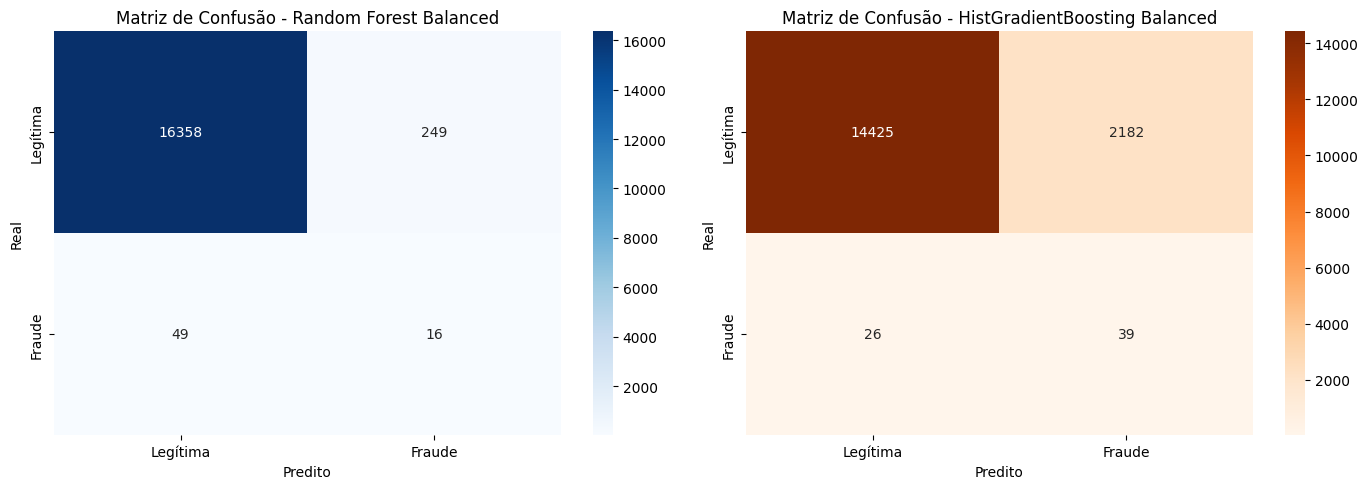

✅ Gráfico 'matrizes_confusao.png' gerado com sucesso!


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando a figura com dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz do Random Forest Balanceado
rf_cm = [[16358, 249], [49, 16]]
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
axes[0].set_title('Matriz de Confusão - Random Forest Balanced')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# Matriz do HistGradientBoosting Balanceado
hgb_cm = [[14425, 2182], [26, 39]]
sns.heatmap(hgb_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
axes[1].set_title('Matriz de Confusão - HistGradientBoosting Balanced')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
# Salva direto na sua pasta para você subir no Overleaf
plt.savefig('matrizes_confusao.png', dpi=300)
plt.show()
print("✅ Gráfico 'matrizes_confusao.png' gerado com sucesso!")